# Livestock data

This notebook contains the methodology for processing livestock data into global maps of protein and energy requirements.

## Resources

The raw datasets used in this analysis are as follows:

In [61]:
# --- Ruminant distributions ---
# We use the Da data as it provides the most realistic distribution patterns of livestock.

GLW_CATTLE_DATA = "../../data/raw/GLW/cattle_2010/5_Ct_2010_Da.tif"
GLW_GOAT_DATA = "../../data/raw/GLW/goats_2010/5_Gt_2010_Da.tif"
GLW_SHEEP_DATA = "../../data/raw/GLW/sheep_2010/5_Sh_2010_Da.tif"
GLW_BUFFALO_DATA = "../../data/raw/GLW/buffalo_2010/5_Bf_2010_Da.tif"

# --- Ruminant protein/energy requirement lookup table

REQUIREMENT_LOOKUP_DATA = "../../data/processed/ruminant_macronutrient_requirement_table.csv"



---

## Read in and count GLW data

First we'll read in the raw livestock data

In [62]:
import rasterio

cattle = rasterio.open(GLW_CATTLE_DATA)
cattle_arr = cattle.read(1)
cattle_affine = cattle.transform
cattle.close()

goat = rasterio.open(GLW_GOAT_DATA)
goat_arr = goat.read(1)
goat_affine = goat.transform
goat.close()

sheep = rasterio.open(GLW_SHEEP_DATA)
sheep_arr = sheep.read(1)
sheep_affine = sheep.transform
sheep.close()

buffalo = rasterio.open(GLW_BUFFALO_DATA)
buffalo_arr = buffalo.read(1)
buffalo_affine = buffalo.transform
buffalo.close()

Let's count the total number of each ruminant type

In [63]:
import numpy as np

cattle_arr[cattle_arr == cattle.nodata] = 0
goat_arr[goat_arr == goat.nodata] = 0
sheep_arr[sheep_arr == sheep.nodata] = 0
buffalo_arr[buffalo_arr == buffalo.nodata] = 0

cattle_sum = cattle_arr.sum()
goat_sum = goat_arr.sum()
buffalo_sum = buffalo_arr.sum()
sheep_sum = sheep_arr.sum()

print(f"Total number of cattle is: {round(cattle_sum):,}")
print(f"Total number of goat is: {round(goat_sum):,}")
print(f"Total number of sheep is: {round(sheep_sum):,}")
print(f"Total number of buffalo is: {round(buffalo_sum):,}")

Total number of cattle is: 1,457,227,527
Total number of goat is: 957,171,467
Total number of sheep is: 1,124,176,437
Total number of buffalo is: 190,804,561


---

## Calculate consumption requirements as a spatial distrution

Each ruminant type has an average weight, determined by region, accessed via a lookup table. We use this lookup table to calculate two arrays for each species: one for protein requirements and one for energy requirements. We then sum arrays across species to reach two final arrays: global protein requirements across all species, and global energy requirements across all species. 

In [64]:
import pandas as pd

req_lookup = pd.read_csv(REQUIREMENT_LOOKUP_DATA, index_col=["region_code", "species"], keep_default_na=False)
req_lookup.sample(5)

region_name  adult_female_weight  \
region_code species                                                         
NENA        Goat          Near East and North Africa                 37.0   
SSA         Sheep                 Sub-saharan Africa                 32.0   
RUS         Goat                              Russia                 55.0   
            Beef cattle                       Russia                530.0   
EE          Dairy cattle              Eastern Europe                514.0   

                          adult_male_weight  child_weight  \
region_code species                                         
NENA        Goat                       53.0           2.7   
SSA         Sheep                      42.0           3.2   
RUS         Goat                      100.0           2.2   
            Beef cattle               689.0          35.0   
EE          Dairy cattle              669.0          34.0   

                          adult_female_protein_req  adult_male_protein_req  \
region_code species                                                          
NENA        Goat                          0.061270                0.077959   
SSA         Sheep                         0.078912                0.087982   
RUS         Goat                          0.080045                0.126984   
            Beef cattle                   0.515880                0.719287   
EE          Dairy cattle                  0.503144                0.701627   

                          child_protein_req  adult_female_energy_req  \
region_code species                                                    
NENA        Goat                   0.012744                 2.744907   
SSA         Sheep                  0.013424                 2.569075   
RUS         Goat                   0.012063                 3.870577   
            Beef cattle            0.083500                62.012631   
EE          Dairy cattle           0.082400                60.657275   

                          adult_male_energy_req  child_energy_req  \
region_code species                                                 
NENA        Goat                       3.752281          0.299200   
SSA         Sheep                      3.216014          1.010408   
RUS         Goat                       6.084281          0.244753   
            Beef cattle               83.447776          6.582917   
EE          Dairy cattle              81.975469          6.399933   

                          dairy_cattle_ratio  adult_female_fraction  \
region_code species                                                   
NENA        Goat                    0.514362               0.490000   
SSA         Sheep                   0.734972               0.490000   
RUS         Goat                    0.472624               0.490000   
            Beef cattle             0.472624               0.158213   
EE          Dairy cattle            0.480588               0.235488   

                          adult_male_fraction  child_fraction  
region_code species                                            
NENA        Goat                     0.010000        0.500000  
SSA         Sheep                    0.010000        0.500000  
RUS         Goat                     0.010000        0.500000  
            Beef cattle              0.105475        0.263688  
EE          Dairy cattle             0.004806        0.240294

In [65]:
req_lookup.loc["NA", "Sheep"]

region_name                 North America
adult_female_weight                  82.0
adult_male_weight                   111.0
child_weight                          4.3
adult_female_protein_req         0.124263
adult_male_protein_req           0.150567
child_protein_req                0.014921
adult_female_energy_req          5.061403
adult_male_energy_req            5.656573
child_energy_req                 1.342821
dairy_cattle_ratio               0.205436
adult_female_fraction                0.49
adult_male_fraction                  0.01
child_fraction                        0.5
Name: (NA, Sheep), dtype: object

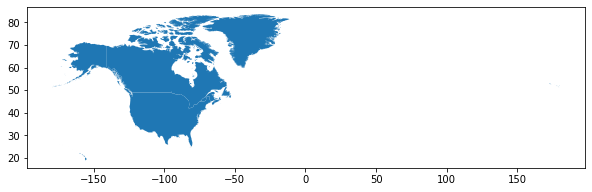

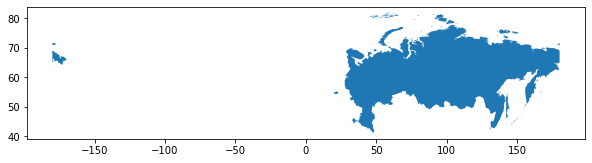

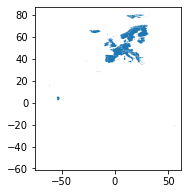

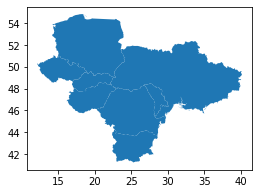

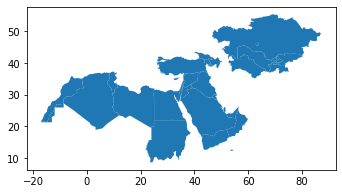

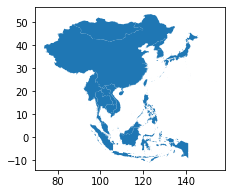

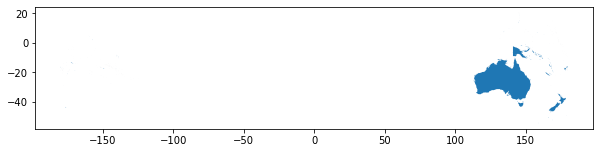

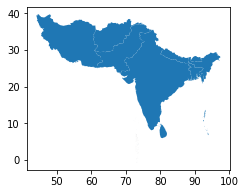

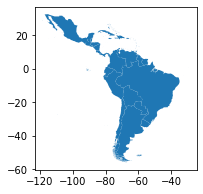

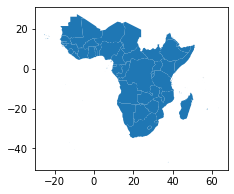

In [80]:
import geopandas as gpd
from rasterio import features
import time
from collections import defaultdict

regions = ["NA", "RUS", "WE", "EE", "NENA", "ESEA", "OCE", "SA", "LAC", "SSA"]
species = {
    "Sheep": [sheep, sheep_arr], 
    "Goat": [goat, goat_arr], 
    "Beef cattle": [cattle, cattle_arr], 
    "Dairy cattle": [cattle, cattle_arr], 
    "Buffalo": [buffalo, buffalo_arr], 
}

country_boundaries = gpd.read_file("../../data/processed/ne_boundaries_gaul.gpkg", driver="GPKG")

results = {
    "Sheep": {
        "NA": {},
        "RUS": {},
        "WE": {},
        "EE": {},
        "NENA": {},
        "ESEA": {},
        "OCE": {},
        "SA": {},
        "LAC": {},
        "SSA": {},
    },
    "Goat": {
        "NA": {},
        "RUS": {},
        "WE": {},
        "EE": {},
        "NENA": {},
        "ESEA": {},
        "OCE": {},
        "SA": {},
        "LAC": {},
        "SSA": {},
    },
    "Beef cattle": {
        "NA": {},
        "RUS": {},
        "WE": {},
        "EE": {},
        "NENA": {},
        "ESEA": {},
        "OCE": {},
        "SA": {},
        "LAC": {},
        "SSA": {},
    },
    "Dairy cattle": {
        "NA": {},
        "RUS": {},
        "WE": {},
        "EE": {},
        "NENA": {},
        "ESEA": {},
        "OCE": {},
        "SA": {},
        "LAC": {},
        "SSA": {},
    },
    "Buffalo": {
        "NA": {},
        "RUS": {},
        "WE": {},
        "EE": {},
        "NENA": {},
        "ESEA": {},
        "OCE": {},
        "SA": {},
        "LAC": {},
        "SSA": {},
    },
}

# We're creating 2 outputs:
# - global array of protein requirements for each species
# - global array of energy requirements for each species

for region in regions:
    
    # Get the countries in our region and plot them
    countries_in_region = country_boundaries[country_boundaries.FAO_REGION == region]
    countries_in_region.plot(figsize=(10,3))
    time.sleep(0.1)
    
    for species_name, species_pop_data in species.items():
        
        lookup_data = req_lookup.loc[region, species_name]
    
        # Convert the geometries into pixel arrays for our key attributes
        
        # Weight
        adult_female_weight = features.rasterize(
            ((g[1].geometry, lookup_data.adult_female_weight) for g in countries_in_region.iterrows()),
            out_shape=species_pop_data[0].shape,
            transform=species_pop_data[0].transform
        )
        adult_male_weight = features.rasterize(
            ((g[1].geometry, lookup_data.adult_male_weight) for g in countries_in_region.iterrows()),
            out_shape=species_pop_data[0].shape,
            transform=species_pop_data[0].transform
        )
        child_weight = features.rasterize(
            ((g[1].geometry, lookup_data.child_weight) for g in countries_in_region.iterrows()),
            out_shape=species_pop_data[0].shape,
            transform=species_pop_data[0].transform
        )
        # Protein
        adult_female_protein_req = features.rasterize(
            ((g[1].geometry, lookup_data.adult_female_protein_req) for g in countries_in_region.iterrows()),
            out_shape=species_pop_data[0].shape,
            transform=species_pop_data[0].transform
        )
        adult_male_protein_req = features.rasterize(
            ((g[1].geometry, lookup_data.adult_male_protein_req) for g in countries_in_region.iterrows()),
            out_shape=species_pop_data[0].shape,
            transform=species_pop_data[0].transform
        )
        child_protein_req = features.rasterize(
            ((g[1].geometry, lookup_data.child_protein_req) for g in countries_in_region.iterrows()),
            out_shape=species_pop_data[0].shape,
            transform=species_pop_data[0].transform
        )
        # Energy
        adult_female_energy_req = features.rasterize(
            ((g[1].geometry, lookup_data.adult_female_energy_req) for g in countries_in_region.iterrows()),
            out_shape=species_pop_data[0].shape,
            transform=species_pop_data[0].transform
        )
        adult_male_energy_req = features.rasterize(
            ((g[1].geometry, lookup_data.adult_male_energy_req) for g in countries_in_region.iterrows()),
            out_shape=species_pop_data[0].shape,
            transform=species_pop_data[0].transform
        )
        child_energy_req = features.rasterize(
            ((g[1].geometry, lookup_data.child_energy_req) for g in countries_in_region.iterrows()),
            out_shape=species_pop_data[0].shape,
            transform=species_pop_data[0].transform
        )
        # Population fractions
        adult_female_fraction = features.rasterize(
            ((g[1].geometry, lookup_data.adult_female_fraction) for g in countries_in_region.iterrows()),
            out_shape=species_pop_data[0].shape,
            transform=species_pop_data[0].transform
        )
        adult_male_fraction = features.rasterize(
            ((g[1].geometry, lookup_data.adult_male_fraction) for g in countries_in_region.iterrows()),
            out_shape=species_pop_data[0].shape,
            transform=species_pop_data[0].transform
        )
        child_fraction = features.rasterize(
            ((g[1].geometry, lookup_data.child_fraction) for g in countries_in_region.iterrows()),
            out_shape=species_pop_data[0].shape,
            transform=species_pop_data[0].transform
        )
        # Dairy cattle ratio
        dairy_cattle_ratio = features.rasterize(
            ((g[1].geometry, lookup_data.dairy_cattle_ratio) for g in countries_in_region.iterrows()),
            out_shape=species_pop_data[0].shape,
            transform=species_pop_data[0].transform
        )
        
        # Now we calculate a protein array for this species and region:
        adult_female_protein_needs = species_pop_data[1] * adult_female_fraction * adult_female_protein_req
        adult_male_protein_needs = species_pop_data[1] * adult_male_fraction * adult_male_protein_req
        child_protein_needs = species_pop_data[1] * child_fraction * child_protein_req
        total_protein_needs = adult_female_protein_needs + adult_male_protein_needs + child_protein_needs
        
        # And energy:
        adult_female_energy_needs = species_pop_data[1] * adult_female_fraction * adult_female_energy_req
        adult_male_energy_needs = species_pop_data[1] * adult_male_fraction * adult_male_energy_req
        child_energy_needs = species_pop_data[1] * child_fraction * child_energy_req
        total_energy_needs = adult_female_energy_needs + adult_male_energy_needs + child_energy_needs
        
        results[species_name][region]["protein"] = total_protein_needs
        results[species_name][region]["energy"] = total_energy_needs

In [88]:
# Sum results for each species and write the results
protein_all_species_flag = False
energy_all_species_flag = False

for species_name, regional_results in results.items():
    
    total_protein = sum([v["protein"] for _, v in regional_results.items()])
    total_energy = sum([v["energy"] for _, v in regional_results.items()])
    
    # Write species datasets
    species_name_lower = species_name.lower().replace(" ", "_")
    protein_dataset_name = f"../../data/processed/{species_name_lower}_global_protein_requirements_kg_per_day.tif"
    energy_dataset_name = f"../../data/processed/{species_name_lower}_global_energy_requirements_mj_per_day.tif"

    protein_dataset = rasterio.open(
        protein_dataset_name,
        "w",
        driver="GTiff",
        height=total_protein.shape[0],
        width=total_protein.shape[1],
        count=1,
        dtype=total_protein.dtype,
        crs='+proj=latlong',
        transform=species[species_name][0].transform
    )
    protein_dataset.write(total_protein, 1)
    protein_dataset.close()
    
    energy_dataset = rasterio.open(
        energy_dataset_name,
        "w",
        driver="GTiff",
        height=total_energy.shape[0],
        width=total_energy.shape[1],
        count=1,
        dtype=total_energy.dtype,
        crs='+proj=latlong',
        transform=species[species_name][0].transform
    )
    energy_dataset.write(total_energy, 1)
    energy_dataset.close()
    
    
    # Add to all species total
    if not protein_all_species_flag:
        protein_all_species = total_protein
        protein_all_species_flag = True
    if not energy_all_species_flag:
        energy_all_species = total_energy
        energy_all_species_flag = True
        
    protein_all_species = protein_all_species + total_protein
    energy_all_species = energy_all_species + total_energy

# Write all species values
protein_all_species_dataset = rasterio.open(
    "../../data/processed/all_species_global_protein_requirements_kg_per_day",
    "w",
    driver="GTiff",
    height=protein_all_species.shape[0],
    width=protein_all_species.shape[1],
    count=1,
    dtype=protein_all_species.dtype,
    crs='+proj=latlong',
    transform=species[species_name][0].transform
)
protein_all_species_dataset.write(protein_all_species, 1)
protein_all_species_dataset.close()

energy_all_species_dataset = rasterio.open(
    "../../data/processed/all_species_global_energy_requirements_mj_per_day",
    "w",
    driver="GTiff",
    height=energy_all_species.shape[0],
    width=energy_all_species.shape[1],
    count=1,
    dtype=energy_all_species.dtype,
    crs='+proj=latlong',
    transform=species[species_name][0].transform
)
energy_all_species_dataset.write(energy_all_species, 1)
energy_all_species_dataset.close()
